# Filtrado en el dominio de la frecuencia

# Filtro pasa bajas

## Filtro pasa altas

## Filtro Butterworth

## Dark channel prior

# Histograma

## Método Otsu

## Ecualizacion del histograma

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [26]:
ruta = '../imagenes/carro.png'
ima_color = cv2.imread(ruta, cv2.IMREAD_COLOR)
C_rojo = np.array(ima_color[:, :, 2]) # BGR para OpenCV
ima_gray = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

In [24]:
# Usamos máscaras para umbralizar los rojos arriba de 150:
n = 100
mascara_rojo_altos = C_rojo >= n
mascara_rojo_bajos = C_rojo < 255 - n
# Creamos una copia de rojos para poder aplicar los cambios
C_rojo_copia = C_rojo.copy()
# Aplicamos la mascara
C_rojo_copia[mascara_rojo_altos] = 255
C_rojo_copia[mascara_rojo_bajos] = 0    

Text(0.5, 1.0, 'Rojos umbralizados')

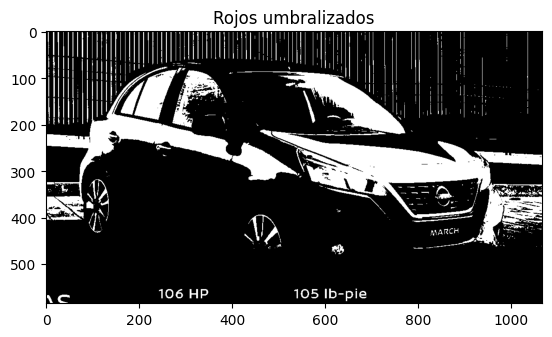

In [25]:
plt.imshow(C_rojo_copia, cmap='gray')
plt.title('Rojos umbralizados')

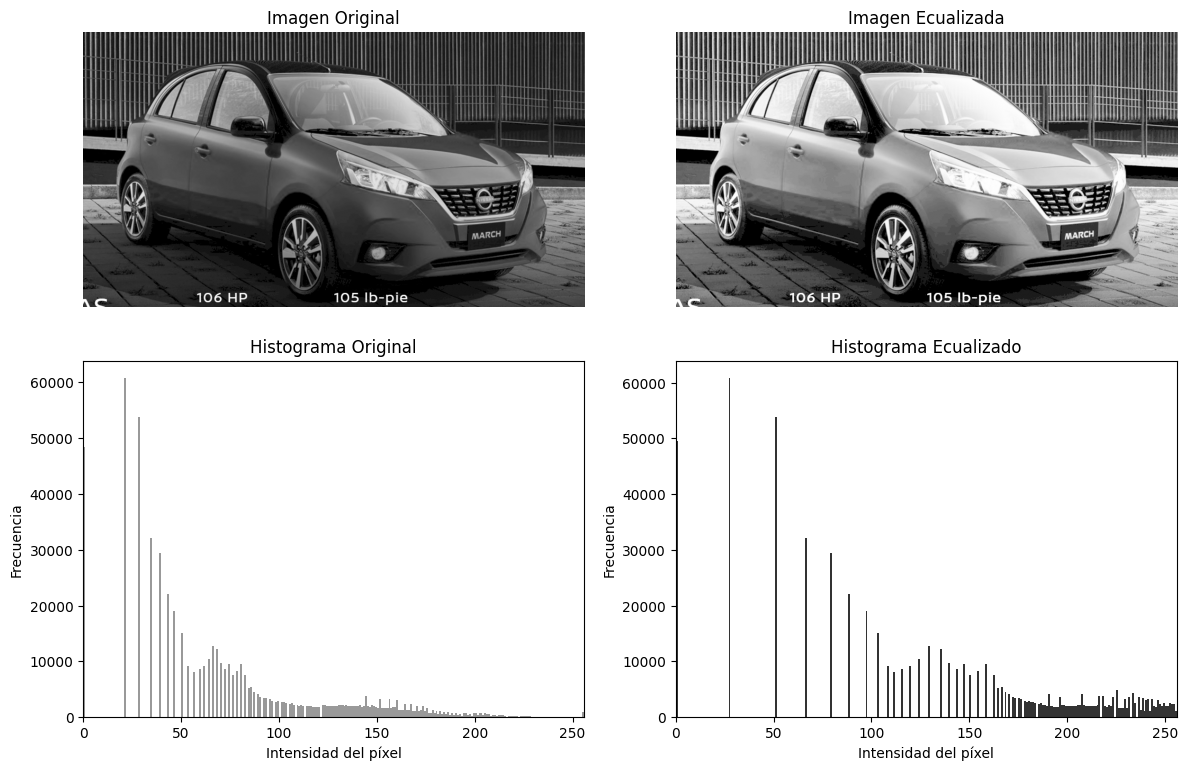

In [31]:
# 1. Ecualización del histograma
equ = cv2.equalizeHist(ima_gray)

# 2. Configuración del lienzo de Matplotlib (Grid de 2x2)
plt.figure(figsize=(12, 8))

# --- Fila 1: Imágenes ---

# Imagen original (Fila 1, Columna 1)
plt.subplot(2, 2, 1)
plt.imshow(ima_gray, cmap='gray')  
plt.title('Imagen Original')
plt.axis('off') # Apagar los ejes para una visualización más limpia

# Imagen ecualizada (Fila 1, Columna 2)
plt.subplot(2, 2, 2)
plt.imshow(equ, cmap='gray')
plt.title('Imagen Ecualizada')
plt.axis('off')

# --- Fila 2: Histogramas ---

# Histograma de la imagen original (Fila 2, Columna 1)
plt.subplot(2, 2, 3)
# Usamos .ravel() para aplanar la matriz 2D a un vector 1D, necesario para plt.hist
plt.hist(ima_gray.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.8)
plt.title('Histograma Original')
plt.xlabel('Intensidad del píxel')
plt.ylabel('Frecuencia')
plt.xlim([0, 256])

# Histograma de la imagen ecualizada (Fila 2, Columna 2)
plt.subplot(2, 2, 4)
plt.hist(equ.ravel(), bins=256, range=[0, 256], color='black', alpha=0.8)
plt.title('Histograma Ecualizado')
plt.xlabel('Intensidad del píxel')
plt.ylabel('Frecuencia')
plt.xlim([0, 256])

# Ajustar automáticamente el espaciado para que no se superpongan los textos
plt.tight_layout()
plt.show()


# Descriptores 

Sirve para identificar un objeto en una imagen.

Cosas que deben tener los descriptores:
- inehrente a rotación
- ineherente a la escala

## Descriptores SHIFT y ORB

### SHIFT
Es un método que usa gradientes:
- Se calcula un gradiente para cada píxel.
- Agrupará vecinos.
- Genera un keypoint descriptor, donde junta las vecindades y suma todos los gradientes de esa posición (vecindad)
- Tendrá gradientes de 0 a 2 $\pi$

### ORB
Arroja todos los puntos y los va a optimizar (escoge cual es más importante), esto apartir de los puntos que salgan del SHIFT. 
- Feature distance: identifica puntos que tienen gradientes muy parecidos o iguales, ya que la imagen aunque esté en otra posición tiene el mismo gradiente.

# Detectores de esquinas

## Test de Harry

## Maxtree

## Segmen anything

# Reconocimiento de Patrones
Aplicaciones:
- Reconocimiento de rostros
  - Cascade classification
  - Deepface
  - VGG-Face
  - Facenet512
- Reconocimiento de huellas
- 
- Vectores
- 